# Google Colab 데이터 로드

In [ ]:
#Step 1. 구글 코랩에 한글 폰트 설정하기

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [ ]:
#Step 2.분석할 데이터가 저장된 파일을 불러와서 변수에 할당합니다.
from google.colab import files
myfile = files.upload()
import io
import pandas as pd
#pd.read_csv로 csv파일 불러오기
과일채소목록 = pd.read_csv(io.BytesIO(myfile['과일채소목록.csv']),
                       encoding='cp949')
과일채소목록

# 로컬 데이터 로드

In [1]:
#컴퓨터에서 작업하려면 아래 코드의 주석을 제거하고 실행하면 됩니다
import pandas as pd
src_data = pd.read_csv('D:/2604340036 - 송성민/Lengchain/머신러닝/회귀, 분류\머신러닝실습용자료/과일채소목록.csv',encoding='cp949')
src_data

,종류,무게_g,길이_cm,색상,당도
0,수박,2000,30.0,1,8.0
1,수박,2500,25.0,1,7.0
2,수박,1800,20.0,1,6.5
3,수박,1500,16.0,1,8.5
4,수박,2200,21.0,1,9.5
5,자두,100,3.5,3,6.0
6,자두,120,3.7,3,7.0
7,자두,90,2.8,3,8.0
8,자두,150,3.8,3,8.5
9,자두,110,3.6,3,7.5


# 공통 실습 코드

In [ ]:
#Step 3. 훈련용 세트와 테스트용 세트로 나눕니다.
# '무게_g','길이_cm','색상','당도'에 따른 과일종류 분류
data = data = src_data[['무게_g', '길이_cm', '색상', '당도']]
target = src_data['종류']

# train, test 데이터 분리
from sklearn.model_selection import train_test_split
훈련용_data, 테스트용_data, 훈련용_target, 테스트용_target = train_test_split(data, target, test_size=0.25, random_state=42)

In [4]:
# 각각의 데이터 확인
print(훈련용_data.shape , 테스트용_data.shape)
print(훈련용_data)
print(훈련용_target)

(37, 4) (13, 4)
    무게_g  길이_cm  색상   당도
8    150    3.8   3  8.5
3   1500   16.0   1  8.5
6    120    3.7   3  7.0
41   501   25.1   1  2.1
46   251   25.1   3  7.6
47   221   22.1   3  7.1
15   450   20.0   1  3.0
9    110    3.6   3  7.5
16   500   25.0   1  2.0
24   290   29.0   3  9.0
34   111    3.7   3  7.6
31   121    3.8   3  7.1
0   2000   30.0   1  8.0
44   351   20.1   1  1.4
27  1801   20.1   1  6.6
33   151    3.9   3  8.6
5    100    3.5   3  6.0
29  2201   21.1   1  9.6
11   400    7.5   2  7.2
36   401    7.6   2  7.3
1   2500   25.0   1  7.0
21   250   25.0   3  7.5
2   1800   20.0   1  6.5
43   401   23.1   1  1.1
35   501    8.1   2  8.1
23   270   26.0   3  8.5
40   451   20.1   1  3.1
10   500    8.0   2  8.0
22   220   22.0   3  7.0
18   400   23.0   1  1.0
49   291   29.1   3  9.1
20   280   28.0   3  8.0
7     90    2.8   3  8.0
42   381   22.1   1  1.6
14   600    8.5   2  8.0
28  1501   16.1   1  8.6
38   401    6.6   2  6.6
8       자두
3       수박
6       자두
4

In [5]:
from sklearn.ensemble import RandomForestClassifier
# 랜덤 포레스트 모델 생성
rf = RandomForestClassifier(n_estimators=10, n_jobs=-1, random_state=40)
# 학습
rf.fit(훈련용_data, 훈련용_target)
# 예측
print(rf.predict(테스트용_data))
# score
print(rf.score(테스트용_data, 테스트용_target))

['참외' '참외' '자두' '거봉포도' '옥수수' '거봉포도' '수박' '수박' '자두' '옥수수' '참외' '수박' '참외']
1.0


### 결과표 작성 및 시각화

In [6]:
# 테스트 데이터 확인
import pandas as pd

결과표 = pd.DataFrame({
    '실제 정답': 테스트용_target,
    '모델 예측값': rf.predict(테스트용_data)
})

In [7]:
# 예측결과 데이터프레임을 만들고
예측결과 = pd.DataFrame(rf.predict(테스트용_data), columns=['예측결과'])
# concat을 통해 기존 테스트 data와 예측결과 데이터를 합친다.
result = pd.concat([테스트용_data.reset_index(drop=True), 예측결과], axis=1)
result

,무게_g,길이_cm,색상,당도,예측결과
0,400,6.5,2,6.5,참외
1,601,8.6,2,8.1,참외
2,101,3.6,3,6.1,자두
3,281,28.1,3,8.1,거봉포도
4,380,22.0,1,1.5,옥수수
5,271,26.1,3,8.6,거봉포도
6,2501,25.1,1,7.1,수박
7,2001,30.5,1,8.1,수박
8,91,2.9,3,8.1,자두
9,350,20.0,1,1.3,옥수수


In [8]:
from sklearn.metrics import classification_report

#예측
pred = rf.predict(테스트용_data)

#리포트 출력
print(classification_report(테스트용_target, pred))

              precision    recall  f1-score   support

        거봉포도       1.00      1.00      1.00         2
          수박       1.00      1.00      1.00         3
         옥수수       1.00      1.00      1.00         2
          자두       1.00      1.00      1.00         2
          참외       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



In [9]:
# k-fold 교차 검증
# k-fold 교차 검증
from sklearn.model_selection import cross_validate
import numpy as np

# 교차 검증 수행 (기본 5-fold)
# - estimator: 평가할 모델 (rf)
# - X: 전체 데이터 (data)
# - y: 전체 타겟 (target)
scores = cross_validate(rf, data, target, return_train_score=True)

# 검증 결과(테스트 폴드 정확도) 출력
print("각 폴드별 검증 정확도:", np.round(scores['test_score'], 4))
print("평균 검증 정확도:", np.round(np.mean(scores['test_score']), 4))

# 훈련 폴드 정확도 출력 (과대적합 확인용)
print("평균 훈련 정확도:", np.round(np.mean(scores['train_score']), 4))


각 폴드별 검증 정확도: [1. 1. 1. 1. 1.]
평균 검증 정확도: 1.0
평균 훈련 정확도: 1.0


중요속성지표값: [0.43496631 0.2017243  0.16782615 0.19548324]


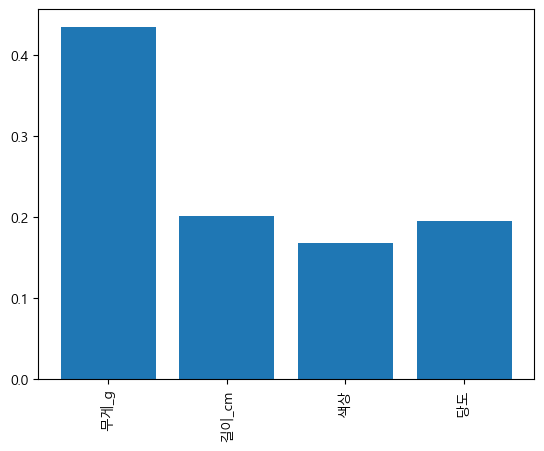

In [10]:
# 중요 속성 지표값 출력

import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

imp = rf.feature_importances_
print('중요속성지표값:',imp)

plt.figure()
plt.bar(range(len(imp)),imp)
plt.xticks(range(len(imp)),data.columns, rotation=90)
plt.show()